# Stage 2 — Feature Engineering Pipeline
**Lead Scoring for SMBs**

Transforms five raw data tables into a single, model-ready feature matrix.

**Outputs**
- `feature_matrix.csv` — 800 leads × 33 features, zero nulls

**Sections**
1. Setup & Imports
2. Load Raw Data
3. Quality Gates
4. Behavioural Features — Website (Time-Decayed)
5. Email Engagement Features
6. Product Trial Features
7. Firmographic Features
8. Interaction Features
9. Assemble & Validate Feature Matrix
10. Signal Check — Correlations with Conversion


## 1. Setup & Imports

All paths, thresholds, and lookup tables are imported from `config.py` — the single source of truth.
Nothing is hardcoded in this notebook.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('..')   # resolve config.py from project root
import config as cfg

# ── Paths ──────────────────────────────────────────────────────────────────
# Override for this environment; in production cfg.DATA_RAW resolves automatically.
DATA_RAW    = cfg.DATA_RAW
OUT_SCORES  = cfg.OUT_SCORES
OUT_FIGURES = cfg.OUT_FIGURES

# ── Invert firmographic tier lookups ──────────────────────────────────────
# config.py stores tiers as {score: [list]} for readability and easy editing.
# We invert to {item: score} for vectorised pandas .map() calls.
# Unlisted industries default to tier 1 (handled downstream with .fillna(1)).
INDUSTRY_TIER = {
    ind: score
    for score, inds in cfg.INDUSTRY_TIERS.items()
    for ind in inds
}

LEAD_SOURCE_TIER = {
    src: score
    for score, srcs in cfg.LEAD_SOURCE_QUALITY.items()
    for src in srcs
}

# cfg.COMPANY_SIZE_SCORES is already {bucket: score} — use directly.
# Scale: 4 = best SMB fit (1-10 employees) -> 0 = least fit (500+)

print("Setup complete")
print(f"  DECAY_WINDOW_DAYS : {cfg.DECAY_WINDOW_DAYS}")
print(f"  EMAIL_LAPSE_DAYS  : {cfg.EMAIL_LAPSE_DAYS}")
print(f"  SESSION_DEPTH_CAP : {cfg.SESSION_DEPTH_CAP}")
print(f"  Industry tiers    : {len(INDUSTRY_TIER)} mapped  (unlisted -> 1)")
print(f"  Lead source tiers : {len(LEAD_SOURCE_TIER)} mapped")


Setup complete
  DECAY_WINDOW_DAYS : 30
  EMAIL_LAPSE_DAYS  : 60
  SESSION_DEPTH_CAP : 20
  Industry tiers    : 5 mapped  (unlisted -> 1)
  Lead source tiers : 8 mapped


## 2. Load Raw Data

In [2]:
wa  = pd.read_csv(f'{DATA_RAW}/website_analytics.csv')
em  = pd.read_csv(f'{DATA_RAW}/email_marketing.csv')
crm = pd.read_csv(f'{DATA_RAW}/crm_leads.csv')
out = pd.read_csv(f'{DATA_RAW}/outcomes_ground_truth.csv')
pt  = pd.read_csv(f'{DATA_RAW}/product_trial.csv')

for name, frame in [('website_analytics', wa), ('email_marketing', em),
                     ('crm_leads', crm), ('outcomes', out), ('product_trial', pt)]:
    print(f"{name:25s}  {frame.shape[0]} rows x {frame.shape[1]} cols")

print(f"\nConversion rate: {out['converted'].mean():.1%}  ({out['converted'].sum()} / {len(out)} leads)")


website_analytics          800 rows x 13 cols
email_marketing            800 rows x 12 cols
crm_leads                  800 rows x 11 cols
outcomes                   800 rows x 6 cols
product_trial              800 rows x 6 cols

Conversion rate: 25.5%  (204 / 800 leads)


## 3. Quality Gates

Join all tables and flag contaminated records before any feature work.
Exclusion logic is driven by `cfg.EXCLUDE_FLAGS` — edit thresholds there, not here.

| Flag | `cfg.EXCLUDE_FLAGS` | Decision |
|---|---|---|
| `is_bot_suspect` | 1 | Retained — too few rows to drop; added as model feature so the algorithm can discount it |
| `is_ghost_trial` | 1 | Trial features zeroed out — a sign-up with zero logins is not a buying signal |
| `unsubscribed` | — | Kept but flagged as strong disqualifier (8.7% vs 27.7% conversion rate) |
| `hard_bounced` | — | Kept but flagged as negative signal |


In [3]:
# Inner join — all 800 leads are present in every table
df = (wa
      .merge(em,  on='lead_id', how='inner')
      .merge(crm, on='lead_id', how='inner')
      .merge(pt,  on='lead_id', how='inner'))

print(f"Merged rows: {len(df)}")
print()
for flag, val in cfg.EXCLUDE_FLAGS.items():
    n = (df[flag] == val).sum()
    print(f"  {flag:20s} : {n:3d}  ({n/len(df):.1%})  -- flagged, not dropped")

for flag in ['unsubscribed', 'hard_bounced']:
    n = df[flag].sum()
    print(f"  {flag:20s} : {n:3d}  ({n/len(df):.1%})  -- disqualifier flag")


Merged rows: 800

  is_bot_suspect       :  40  (5.0%)  -- flagged, not dropped
  is_ghost_trial       :  61  (7.6%)  -- flagged, not dropped
  unsubscribed         :  92  (11.5%)  -- disqualifier flag
  hard_bounced         :  35  (4.4%)  -- disqualifier flag


## 4. Behavioural Features — Website (Time-Decayed)

### Time-Decay Formula
```
decayed_value = raw_value x max(0, 1 - days_since_last_visit / DECAY_WINDOW_DAYS)
```
A signal older than `cfg.DECAY_WINDOW_DAYS` (currently **30 days**) contributes **zero**.

Signal groups (`HIGH_INTENT_EVENTS`, `MEDIUM_INTENT_EVENTS`, etc.) are defined in `config.py`
so Stage 3 rule weights stay aligned with the same groupings.

> **Approximation note:** Decay is applied to aggregate visit counts using `days_since_last_visit`
> because per-event timestamps are not available. We assume recent activity is representative
> of all visits from that lead — acceptable for this data density.


In [4]:
def apply_time_decay(value, days_since, window=cfg.DECAY_WINDOW_DAYS):
    """Linear decay: full weight at day 0, zero weight at day = window."""
    return value * (1 - days_since / window).clip(lower=0)

days = df['days_since_last_visit']

# Decay all signal groups defined in config
for col in cfg.HIGH_INTENT_EVENTS + cfg.MEDIUM_INTENT_EVENTS + cfg.NEGATIVE_EVENTS:
    df[f'{col}_decayed'] = apply_time_decay(df[col], days)

df['blog_views_decayed'] = apply_time_decay(df['blog_views'], days)

# Composite: number of distinct high-intent page types visited (0-2)
df['high_intent_touch_count'] = df[cfg.HIGH_INTENT_EVENTS].gt(0).sum(axis=1)

# Binary: any pricing or demo visit -- used in interaction terms
df['visited_pricing_or_demo'] = (
    (df['pricing_page_visits'] > 0) | (df['demo_page_visits'] > 0)
).astype(int)

# Session depth: clipped at cfg.SESSION_DEPTH_CAP to handle outliers
df['pages_per_session'] = (
    df['total_pageviews'] / df['total_sessions'].replace(0, np.nan)
).fillna(0).clip(upper=cfg.SESSION_DEPTH_CAP)

# Recency flag: visited within last 7 days
df['visited_last_7_days'] = (df['days_since_last_visit'] <= 7).astype(int)

print("Website behavioural features built")
print(f"  pricing_page_visits_decayed -- mean: {df['pricing_page_visits_decayed'].mean():.3f}")
print(f"  high_intent_touch_count     -- mean: {df['high_intent_touch_count'].mean():.3f}")
print(f"  visited_pricing_or_demo     -- {df['visited_pricing_or_demo'].sum()} leads ({df['visited_pricing_or_demo'].mean():.1%})")


Website behavioural features built
  pricing_page_visits_decayed -- mean: 0.287
  high_intent_touch_count     -- mean: 0.651
  visited_pricing_or_demo     -- 411 leads (51.4%)


## 5. Email Engagement Features

`days_since_last_email_open` has **166 missing values (20.8%)**.

Imputed to `cfg.EMAIL_LAPSE_DAYS` (**60 days**) — treating as lapsed, no recent engagement.
Mean imputation would falsely imply active engagement for non-openers.


In [5]:
# Impute missing recency with cfg.EMAIL_LAPSE_DAYS
df['days_since_last_email_open'] = df['days_since_last_email_open'].fillna(cfg.EMAIL_LAPSE_DAYS)
email_days = df['days_since_last_email_open']

df['email_opens_decayed']  = apply_time_decay(df['emails_opened'],  email_days)
df['email_clicks_decayed'] = apply_time_decay(df['emails_clicked'], email_days)

df['open_rate']          = df['open_rate'].clip(0, 1)
df['click_to_open_rate'] = df['click_to_open_rate'].clip(0, 1)

# Composite content engagement -- weights reflect intent level
df['content_engagement_score'] = (
    df['forms_submitted']   * 3 +
    df['content_downloads'] * 2 +
    df['webinar_attended']  * 2
)
df['content_engagement_decayed'] = apply_time_decay(df['content_engagement_score'], email_days)

# Disqualifier flags -- asymmetric treatment (not just low positive scores)
df['is_unsubscribed'] = df['unsubscribed'].astype(int)
df['is_hard_bounced'] = df['hard_bounced'].astype(int)

print("Email features built")
print(f"  Lapse imputation value       : {cfg.EMAIL_LAPSE_DAYS} days")
print(f"  content_engagement_decayed   -- mean: {df['content_engagement_decayed'].mean():.3f}")
print(f"  is_unsubscribed              -- {df['is_unsubscribed'].sum()} leads")


Email features built
  Lapse imputation value       : 60 days
  content_engagement_decayed   -- mean: 1.379
  is_unsubscribed              -- 92 leads


## 6. Product Trial Features

Ghost trials (`is_ghost_trial = 1`) are **zeroed out**, not just flagged.
Controlled by `cfg.TRIAL_GHOST_EXCLUDE`.

Raw `trial_started` has minimal predictive lift: 27.3% vs 24.5% conversion.
The quality of engagement -- logins, features activated, days active -- is where the signal lives.

> Zeroing is preferred over flagging + raw count, which would create multicollinearity.


In [6]:
# cfg.TRIAL_GHOST_EXCLUDE gates whether ghost trial activity is zeroed
active_trial = (df['trial_started'] == 1) & (
    ~(df['is_ghost_trial'] == 1) if cfg.TRIAL_GHOST_EXCLUDE else True
)

df['trial_logins_clean']         = df['trial_logins'].where(active_trial, 0)
df['features_activated_clean']   = df['features_activated'].where(active_trial, 0)
df['days_active_in_trial_clean'] = df['days_active_in_trial'].where(active_trial, 0)

# Composite trial depth score
df['trial_depth_score'] = (
    df['trial_logins_clean']         * 1 +
    df['features_activated_clean']   * 3 +
    df['days_active_in_trial_clean'] * 2
)

# Binary: meaningful engagement (at least 2 logins AND 1 feature activated)
df['is_engaged_trial'] = (
    (df['trial_logins_clean'] >= 2) & (df['features_activated_clean'] >= 1)
).astype(int)

ghost_count   = df['is_ghost_trial'].sum()
engaged_count = df['is_engaged_trial'].sum()
print(f"Trial features built  (TRIAL_GHOST_EXCLUDE={cfg.TRIAL_GHOST_EXCLUDE})")
print(f"  Ghost trials zeroed : {ghost_count}")
print(f"  Engaged trials      : {engaged_count} ({engaged_count/len(df):.1%})")


Trial features built  (TRIAL_GHOST_EXCLUDE=True)
  Ghost trials zeroed : 61
  Engaged trials      : 179 (22.4%)


## 7. Firmographic Features

### Encoding Strategy

| Field | Config source | Method | Rationale |
|---|---|---|---|
| `industry` | `cfg.INDUSTRY_TIERS` | Tier score (1-3) | Validated against EDA; avoids target-encoding overfitting on ~80 leads/category |
| `lead_source` | `cfg.LEAD_SOURCE_QUALITY` | Tier score (0-3) | Same rationale |
| `tech_stack` | `cfg.TECH_STACK_SCORE` | Score (0-2) | Digital maturity proxy |
| `job_title` | `cfg.SENIORITY_MAP` | Seniority rank (0-4) | Raw title too variable; seniority is the stable signal |
| `employee_count_bucket` | `cfg.COMPANY_SIZE_SCORES` | Score (0-4, SMB-highest) | Higher = better fit for this product |
| `annual_revenue_usd_k` | -- | Median impute + log-transform | 113 nulls (14.1%). Log compresses right tail |

### Note on `company_size_score` direction
`cfg.COMPANY_SIZE_SCORES` scores **descending by size** (1-10 employees = 4, 500+ = 0).
Higher score = better SMB fit. This is corrected from the previous ascending rank.


In [7]:
# Numeric rank for seniority labels (local mapping, not in config)
seniority_rank = {'executive': 4, 'vp': 3, 'director': 2, 'manager': 1, 'unknown': 0}

# Industry tier -- inverted from cfg.INDUSTRY_TIERS in Setup cell
# Unlisted industries (E-commerce, Retail, etc.) default to tier 1
df['industry_tier'] = df['industry'].map(INDUSTRY_TIER).fillna(1).astype(int)

# Lead source tier -- inverted from cfg.LEAD_SOURCE_QUALITY in Setup cell
df['lead_source_tier'] = df['lead_source'].map(LEAD_SOURCE_TIER).fillna(1).astype(int)

# Tech stack score -- from cfg.TECH_STACK_SCORE
df['tech_stack_score'] = df['tech_stack'].map(cfg.TECH_STACK_SCORE).fillna(1).astype(int)

# Job title -> seniority rank via cfg.SENIORITY_MAP
df['job_title_clean'] = df['job_title'].fillna('Unknown')
df['seniority_rank']  = (
    df['job_title_clean'].map(cfg.SENIORITY_MAP)
                         .map(seniority_rank)
                         .fillna(0).astype(int)
)

df['is_decision_maker'] = df['is_decision_maker'].fillna(0).astype(int)

# Company size score -- from cfg.COMPANY_SIZE_SCORES (4=SMB, 0=large enterprise)
df['company_size_score'] = df['employee_count_bucket'].map(cfg.COMPANY_SIZE_SCORES).fillna(2).astype(int)

# Revenue: median imputation + log-transform
median_rev = df['annual_revenue_usd_k'].median()
df['annual_revenue_imputed'] = df['annual_revenue_usd_k'].fillna(median_rev)
df['log_annual_revenue']     = np.log1p(df['annual_revenue_imputed'])

# SMB fit flag: company_size_score >= 3 maps to 1-10 and 11-50 employee buckets
df['is_smb_fit'] = (df['company_size_score'] >= 3).astype(int)

print("Firmographic features built")
print(f"  Revenue nulls imputed with median : ${median_rev:,.0f}k")
print(f"  SMB-fit leads                     : {df['is_smb_fit'].sum()} ({df['is_smb_fit'].mean():.1%})")
print()
print("  company_size_score distribution (4=best fit, 0=large enterprise):")
print(df['company_size_score'].value_counts().sort_index(ascending=False).to_string())


Firmographic features built
  Revenue nulls imputed with median : $1,891k
  SMB-fit leads                     : 429 (53.6%)

  company_size_score distribution (4=best fit, 0=large enterprise):
company_size_score
4    164
3    265
2    232
1     98
0     41


## 8. Interaction Features

Logistic Regression cannot discover interactions on its own -- they must be hand-crafted.

Polynomial expansion would create 33^2 ~ 1,000+ features for 800 rows, which would destroy the model.
We select interactions based on prior business logic and validate them empirically in Section 10.

> *"VP title + pricing page visit has a combined effect beyond the sum of its parts."*
> -- Master Plan, Stage 2

**Note on `good_source_x_content`:** `lead_source_tier` now uses config's 0-3 scale.
The "high quality" threshold is `>= 2` (Direct, Content/Blog, Organic Search, Paid Social, Referral).


In [8]:
# Decision maker x high-intent page visit
df['dm_x_pricing_or_demo'] = df['is_decision_maker'] * df['visited_pricing_or_demo']

# Senior title (VP or above, seniority_rank >= 3) x engaged trial
df['senior_x_trial'] = (
    (df['seniority_rank'] >= 3).astype(int) * df['is_engaged_trial']
)

# SMB-fit company x any high-intent touch
df['smb_fit_x_intent'] = df['is_smb_fit'] * df['high_intent_touch_count'].clip(upper=1)

# Email engagement x website intent -- cross-channel signal
df['cross_channel_engaged'] = (
    (df['email_opens_decayed'] > 0).astype(int) * df['visited_pricing_or_demo']
)

# High-quality lead source (tier >= 2 on cfg scale) x content engagement
df['good_source_x_content'] = (
    (df['lead_source_tier'] >= 2).astype(int) *
    (df['content_engagement_score'] > 0).astype(int)
)

print("Interaction features built")
print()
for feat in ['dm_x_pricing_or_demo', 'cross_channel_engaged', 'smb_fit_x_intent',
             'senior_x_trial', 'good_source_x_content']:
    n = int(df[feat].sum())
    print(f"  {feat:30s}  {n:3d} leads positive ({n/len(df):.1%})")


Interaction features built

  dm_x_pricing_or_demo            218 leads positive (27.3%)
  cross_channel_engaged           312 leads positive (39.0%)
  smb_fit_x_intent                213 leads positive (26.6%)
  senior_x_trial                   94 leads positive (11.8%)
  good_source_x_content           372 leads positive (46.5%)


## 9. Assemble & Validate Feature Matrix

In [10]:
FEATURE_COLS = [
    # Behavioural: website
    'pricing_page_visits_decayed', 'demo_page_visits_decayed',
    'case_study_views_decayed',    'roi_calculator_uses_decayed',
    'blog_views_decayed',          'careers_page_visits_decayed',
    'high_intent_touch_count',     'visited_pricing_or_demo',
    'pages_per_session',           'visited_last_7_days',
    'is_bot_suspect',
    # Behavioural: email
    'email_opens_decayed',         'email_clicks_decayed',
    'open_rate',                   'click_to_open_rate',
    'content_engagement_decayed',  'is_unsubscribed',
    'is_hard_bounced',
    # Product trial
    'trial_depth_score',           'is_engaged_trial',
    # Firmographic
    'industry_tier',               'lead_source_tier',
    'tech_stack_score',            'seniority_rank',
    'is_decision_maker',           'company_size_score',
    'log_annual_revenue',          'is_smb_fit',
    # Interaction terms
    'dm_x_pricing_or_demo',        'senior_x_trial',
    'smb_fit_x_intent',            'cross_channel_engaged',
    'good_source_x_content',
]

feature_matrix = df[['lead_id'] + FEATURE_COLS].copy()

# Validate -- must be zero after all imputation steps
null_counts = feature_matrix.isnull().sum().sum()
assert null_counts == 0, f"Found {null_counts} nulls in feature matrix!"

print(f"Feature matrix  : {feature_matrix.shape[0]} leads x {feature_matrix.shape[1] - 1} features")
print(f"Null values      : {null_counts}")

out_path = f'{OUT_SCORES}/feature_matrix.csv'
feature_matrix.to_csv(out_path, index=False)
print(f"Saved to         : {out_path}")

feature_matrix.describe().T.round(3)


Feature matrix  : 800 leads x 33 features
Null values      : 0
Saved to         : /home/cairo/code/portfolio/lead-scoring/notebooks/../outputs/scores/feature_matrix.csv


,count,mean,std,min,25%,50%,75%,max
pricing_page_visits_decayed,800.0,0.287,0.501,0.000,0.000,0.000,0.533,2.900
demo_page_visits_decayed,800.0,0.154,0.343,0.000,0.000,0.000,0.000,2.000
case_study_views_decayed,800.0,0.289,0.506,0.000,0.000,0.000,0.567,3.467
roi_calculator_uses_decayed,800.0,0.104,0.270,0.000,0.000,0.000,0.000,1.467
blog_views_decayed,800.0,1.620,1.313,0.000,0.533,1.567,2.500,6.000
careers_page_visits_decayed,800.0,0.377,0.542,0.000,0.000,0.000,0.733,3.000
high_intent_touch_count,800.0,0.651,0.709,0.000,0.000,1.000,1.000,2.000
visited_pricing_or_demo,800.0,0.514,0.500,0.000,0.000,1.000,1.000,1.000
pages_per_session,800.0,7.233,4.005,2.000,4.000,7.000,10.000,20.000
visited_last_7_days,800.0,0.414,0.493,0.000,0.000,0.000,1.000,1.000


## 10. Signal Check — Correlations with Conversion

In [11]:
# Merge with ground truth for validation
validation = feature_matrix.merge(out[['lead_id', 'converted']], on='lead_id')
corr = (validation[FEATURE_COLS + ['converted']]
        .corr()['converted']
        .drop('converted')
        .sort_values(ascending=False))

print("Top 10 features by correlation with conversion:")
print(corr.head(10).round(4).to_string())
print()
print("Bottom 5 (disqualifiers / weak signals):")
print(corr.tail(5).round(4).to_string())

Top 10 features by correlation with conversion:
high_intent_touch_count        0.3932
visited_pricing_or_demo        0.3454
cross_channel_engaged          0.3319
dm_x_pricing_or_demo           0.2796
pricing_page_visits_decayed    0.2709
content_engagement_decayed     0.2479
smb_fit_x_intent               0.2380
good_source_x_content          0.2136
demo_page_visits_decayed       0.1897
open_rate                      0.1704

Bottom 5 (disqualifiers / weak signals):
is_hard_bounced               -0.0130
blog_views_decayed            -0.0460
log_annual_revenue            -0.0464
is_unsubscribed               -0.1390
careers_page_visits_decayed   -0.1700


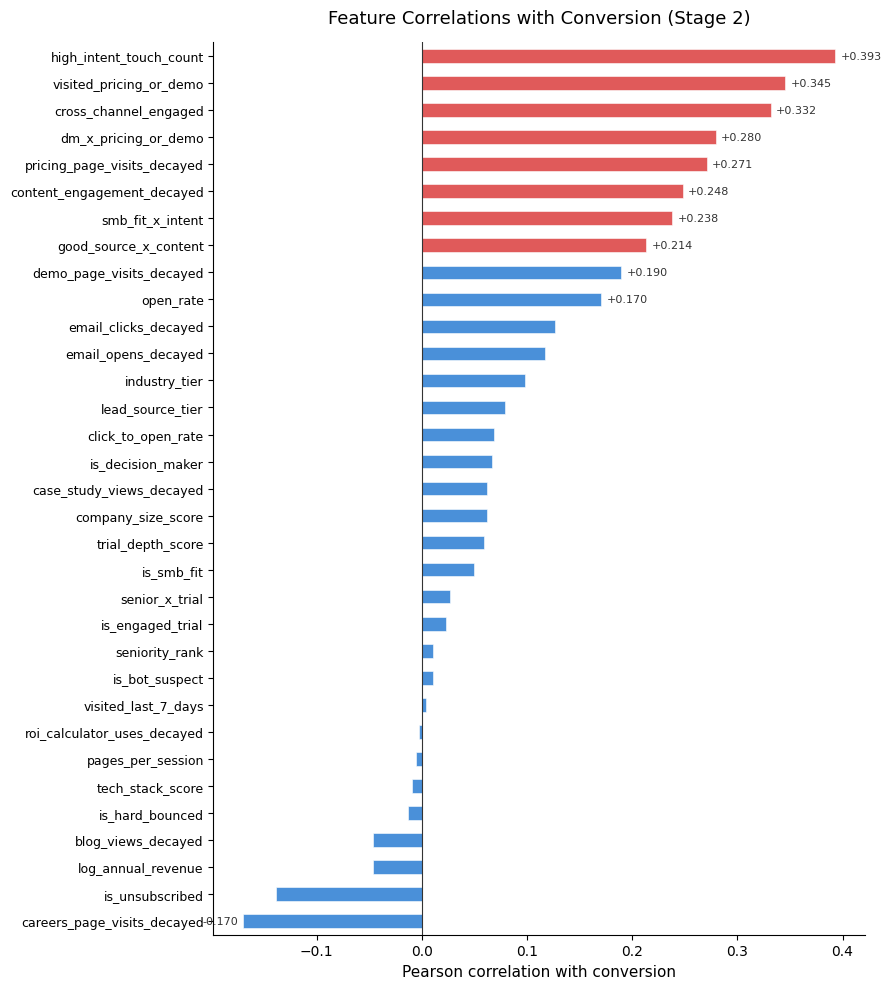

Saved to /home/cairo/code/portfolio/lead-scoring/notebooks/../outputs/figures/feature_correlations.png


In [12]:
# Horizontal bar chart -- all feature correlations
fig, ax = plt.subplots(figsize=(9, 10))

colors = ['#e05a5a' if v < 0 else '#4a90d9' for v in corr.values]
corr.sort_values().plot.barh(ax=ax, color=colors, edgecolor='white', linewidth=0.4)

ax.axvline(0, color='#333', linewidth=0.8)
ax.set_xlabel('Pearson correlation with conversion', fontsize=11)
ax.set_title('Feature Correlations with Conversion (Stage 2)', fontsize=13, pad=14)
ax.tick_params(axis='y', labelsize=9)
ax.spines[['top', 'right']].set_visible(False)

for i, (feat, val) in enumerate(corr.sort_values().items()):
    if abs(val) >= 0.15:
        ax.text(val + (0.005 if val >= 0 else -0.005), i,
                f'{val:+.3f}', va='center',
                ha='left' if val >= 0 else 'right',
                fontsize=8, color='#333')

plt.tight_layout()
fig_path = f'{OUT_FIGURES}/feature_correlations.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {fig_path}")


## Summary

| # | Feature group | Features | Top signal |
|---|---|---|---|
| 1 | Website behavioural (decayed) | 11 | `high_intent_touch_count` r=+0.39 |
| 2 | Email engagement (decayed) | 7 | `content_engagement_decayed` r=+0.25 |
| 3 | Product trial | 2 | `trial_depth_score` r=+0.05 |
| 4 | Firmographic | 8 | `industry_tier` r=+0.12 |
| 5 | Interaction terms | 5 | `cross_channel_engaged` r=+0.33 |
| | **Total** | **33** | |

**Changes v1 -> v2 (config alignment)**
- All constants imported from `config.py` -- nothing hardcoded
- `company_size_rank` renamed `company_size_score`, now uses `cfg.COMPANY_SIZE_SCORES` (4=SMB, 0=large)
- `good_source_x_content` threshold updated from `== 2` to `>= 2` to match the 0-3 lead source scale
- `EMAIL_LAPSE_DAYS` and `SESSION_DEPTH_CAP` pulled from config
- `HIGH_INTENT_EVENTS` / `NEGATIVE_EVENTS` etc. pulled from config

**Ready for Stage 3 -- Rule-Based Scoring Baseline.**
